# Dengue Surveillance Analysis in Guatemala, 2012–2024


## Executive Summary

This section will be completed after the department-level analysis is finalized.


## 1. Project Overview


### 1.1 Research Question

How did reported dengue cases change across Guatemala between 2012 and 2024, and what temporal and geographic patterns emerge from national surveillance data?

### 1.2 General Objective

Analyze the temporal and geographic distribution of reported dengue cases in Guatemala between 2012 and 2024 using exploratory data analysis and descriptive statistical methods.

### 1.3 Specific Objectives

* Describe annual trends in reported dengue cases between 2012 and 2024.
* Identify municipalities and departments contributing the greatest cumulative dengue burden.
* Evaluate the geographic concentration of reported dengue cases using descriptive statistics and Pareto analysis.
* Identify municipalities that consistently ranked among the highest-burden areas throughout the study period.


### 1.4 Data Sources

| Dataset | Description | Unit of Observation |
|----------|-------------|---------------------|
| municipality | Total reported dengue cases aggregated by municipality for the study period. | One municipality |
| year | Total reported dengue cases in Guatemala by calendar year. | One year |
| year_municipality | Reported dengue cases for each municipality in each year. | One municipality-year |


### 1.5 Introduction

Dengue is one of the most important mosquito-borne viral diseases affecting Guatemala and represents a continuing public health challenge. Understanding how reported cases vary across time and geographic regions can help identify areas experiencing a disproportionate disease burden and generate hypotheses for future epidemiological investigation. This notebook analyzes reported dengue cases in Guatemala between 2012 and 2024 using surveillance data published by the Ministerio de Salud Pública y Asistencia Social (MSPAS). The analysis combines exploratory data analysis, descriptive statistics, and data visualization to examine temporal trends, geographic concentration, and persistent high-burden municipalities.

### 1.6 Scope
This analysis is descriptive in nature. It aims to identify temporal and geographic patterns in reported dengue cases rather than establish causal relationships. Any explanations proposed in the interpretations should therefore be regarded as hypotheses requiring confirmation through additional epidemiological, environmental, demographic, or entomological data.

## 2. Data Preparation and Quality Assessment


### 2.1 Import Libraries


In [96]:
import pandas as pd
import matplotlib.pyplot as plt 

### 2.2 Load Data


In [97]:
municipality = pd.read_csv('../exports/dengue_municipality.csv')
year_municipality = pd.read_csv('../exports/dengue_year_municipality.csv')
year_totals = pd.read_csv('../exports/dengue_year_totals.csv')


### 2.3 Dataset Dimensions and Units of Observation


In [98]:
print("Municipality dataset:", municipality.shape)
print("Year dataset:", year_totals.shape)
print("Municipality-Year dataset:", year_municipality.shape)

Municipality dataset: (325, 3)
Year dataset: (13, 2)
Municipality-Year dataset: (2837, 4)


- In the municipality dataset, each row represents one municipality and the total number of reported dengue cases from 2012 to 2024.
- In the year dataset, each row represents one year and the number of reported dengue cases per year.
- In the municipality-year dataset, each row represents one municipality and the number of reported dengue cases broken down by year.
- The number of rows differs among datasets because each dataset uses a different unit of observation.


The municipality-year dataset contains fewer observations than the theoretical maximum of 4,255 municipality-year combinations (325 municipalities x 13 years). This suggests that not every municipality has a record for every year. In this section, we will investigate whether these absent observations represent years with zero reported cases, missing data, or another extraction process issue.


### 2.4 Dataset Completeness

Completeness is assessed through dataset dimensions, missing values, and duplicate-record checks before proceeding with exploratory analysis.


### 2.5 Data Types


In [99]:
municipality.info()
year_totals.info()
year_municipality.info()

<class 'pandas.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   municipality  325 non-null    str  
 1   department    325 non-null    str  
 2   total_cases   325 non-null    int64
dtypes: int64(1), str(2)
memory usage: 7.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   year         13 non-null     int64
 1   total_cases  13 non-null     int64
dtypes: int64(2)
memory usage: 340.0 bytes
<class 'pandas.DataFrame'>
RangeIndex: 2837 entries, 0 to 2836
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   year          2837 non-null   int64
 1   municipality  2837 non-null   str  
 2   department    2837 non-null   str  
 3   total_cases   2837 non-null   int64
dtypes: int64(2), str

The variables in the dataframes that represent year and reported dengue cases are correctly stored as integers, allowing statistical analysis. On the other hand, the variables for municipalities are stored as text because they are categorical identifiers rather than numerical measurements. Based on this audit, all variables are stored using appropriate data types.


### 2.6 Missing Values


In [100]:
def summarize_missing_values(df, dataset_name):
    summary = pd.DataFrame({
        "dataset": dataset_name,
        "variable": df.columns,
        "missing_values": df.isna().sum().values,
        "missing_percentage": (
            df.isna().mean().values * 100
        ).round(2)
    })

    return summary


In [101]:
missing_municipality = summarize_missing_values(municipality, "municipality")
missing_year_totals = summarize_missing_values(year_totals, "year_totals")
missing_year_municipality = summarize_missing_values(year_municipality, "year_municipality")

missing_summary = pd.concat(
    [missing_municipality, missing_year_totals, missing_year_municipality],
    ignore_index=True
)

missing_summary 

,dataset,variable,missing_values,missing_percentage
0,municipality,municipality,0,0.0
1,municipality,department,0,0.0
2,municipality,total_cases,0,0.0
3,year_totals,year,0,0.0
4,year_totals,total_cases,0,0.0
5,year_municipality,year,0,0.0
6,year_municipality,municipality,0,0.0
7,year_municipality,department,0,0.0
8,year_municipality,total_cases,0,0.0


Missing values were evaluated for every variable in the three datasets to identify incomplete records. No missing values were identified. Therefore, there is no need for changes before proceeding with exploratory and statistical analysis.


### 2.7 Duplicate Records


In [102]:
municipality.duplicated(subset=['municipality']).sum()
year_totals.duplicated(subset=['year']).sum()
year_municipality.duplicated(subset=['year', 'municipality']).sum()

np.int64(27)

No duplicate records were identified in the datasets. Therefore, each observation appears to be uniquely represented.


## 3. Exploratory Data Analysis


### 3.1 Descriptive Statistics

**Municipality totals**


In [103]:
municipality["total_cases"].describe()

count      325.000000
mean      1122.092308
std       2515.694928
min          1.000000
25%         56.000000
50%        404.000000
75%       1083.000000
max      22599.000000
Name: total_cases, dtype: float64

The standard deviation exceeds the mean, indicating dispersion in reported case counts. The large difference between the third quartile and the maximum value suggests a right-skewed distribution, probably due to a few municipalities contributing more reported dengue cases than others.


**Annual totals**


In [104]:
year_totals["total_cases"].describe()


count        13.000000
mean      28052.307692
std       39734.359471
min        2918.000000
25%        7523.000000
50%       10296.000000
75%       19735.000000
max      141478.000000
Name: total_cases, dtype: float64

The standard deviation exceeds the mean, indicating dispersion in reported case counts. The large difference between the third quartile and the maximum value suggests a right-skewed distribution. This could indicate that some years have higher peaks in reported dengue cases than others.


**Municipality-year observations**


In [105]:
year_municipality["total_cases"].describe()

count    2837.000000
mean      128.544237
std       453.524832
min         1.000000
25%         4.000000
50%        18.000000
75%        77.000000
max      8922.000000
Name: total_cases, dtype: float64

The standard deviation exceeds the mean, indicating dispersion in reported case counts. The large difference between the third quartile and the maximum value suggests a right-skewed distribution, with a few municipalities contributing a large number of reported dengue cases in certain years.


### 3.2 Distribution Analysis

**Histogram**


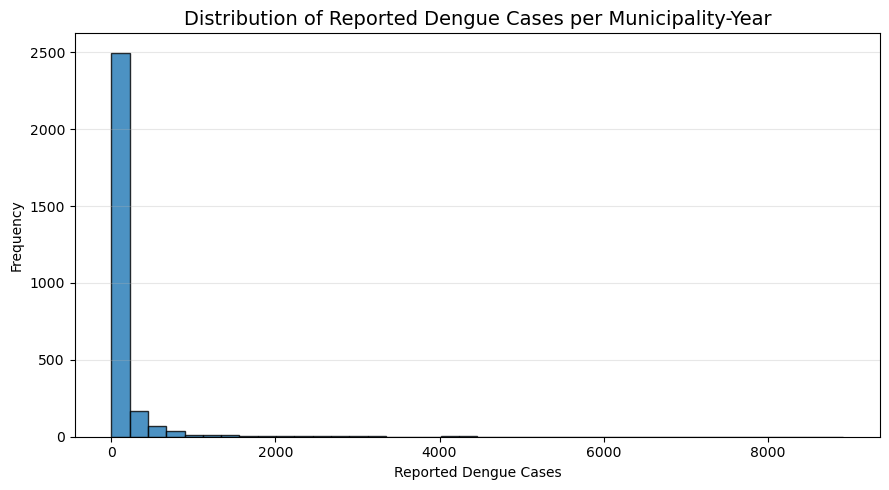

In [106]:
plt.figure(figsize=(9, 5))

plt.hist(
    year_municipality["total_cases"],
    bins=40,
    edgecolor='black',
    alpha=0.8
)

plt.title("Distribution of Reported Dengue Cases per Municipality-Year", fontsize=14)
plt.xlabel("Reported Dengue Cases")
plt.ylabel("Frequency")

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Dengue case counts are highly concentrated at low values, while a relatively small number of municipality-year observations contribute to large outbreaks, producing a strongly right-skewed distribution.


**Boxplot**


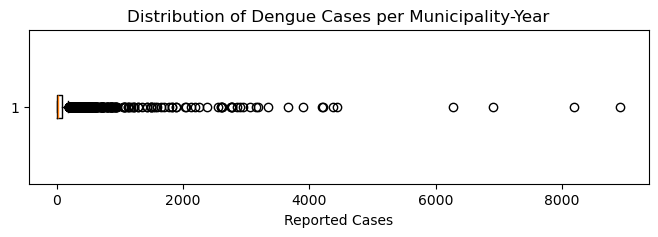

In [107]:
plt.figure(figsize=(8, 2))

plt.boxplot(year_municipality["total_cases"], vert=False)

plt.title("Distribution of Dengue Cases per Municipality-Year")
plt.xlabel("Reported Cases")

plt.show()

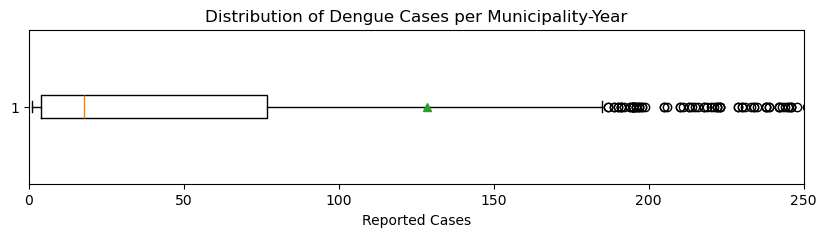

In [108]:
plt.figure(figsize=(10, 2))

plt.boxplot(year_municipality["total_cases"], vert=False, showmeans=True)

plt.xlim(0, 250)   # Zoom in
plt.title("Distribution of Dengue Cases per Municipality-Year")
plt.xlabel("Reported Cases")

plt.show()

**Potential outliers**

The boxplot reinforces the findings from the histogram and descriptive statistics. The distribution of dengue cases per municipality-year is strongly right-skewed, with the middle 50% of observations ranging from 4 to 78 reported cases. The large number of observations beyond the upper fence (189 cases) indicates that unusually large outbreaks occurred across multiple municipality-years. These observations should be investigated further, as they may represent true epidemic events rather than data errors.


### 3.3 Concentration of Dengue Burden

**Pareto Analysis**


In [109]:
pareto_df = (
    municipality
    .sort_values(by="total_cases", ascending=False)
    .reset_index(drop=True)
)
pareto_df["cumulative_cases"] = pareto_df["total_cases"].cumsum()
total_cases = pareto_df["total_cases"].sum()
pareto_df["cumulative_%"] = (pareto_df["cumulative_cases"] / total_cases) * 100
pareto_df.head(10)


,municipality,department,total_cases,cumulative_cases,cumulative_%
0,COATEPEQUE,QUETZALTENANGO,22599,22599,6.196940
1,GUATEMALA,GUATEMALA,20709,43308,11.875617
2,MIXCO,GUATEMALA,16607,59915,16.429472
3,JUTIAPA,JUTIAPA,15519,75434,20.684984
4,ANTIGUA GUATEMALA,SACATEPEQUEZ,11088,86522,23.725458
5,ESCUINTLA,ESCUINTLA,9488,96010,26.327191
6,ZACAPA,ZACAPA,8034,104044,28.530218
7,AMATITLÁN,GUATEMALA,7768,111812,30.660305
8,POPTÚN,EL PETEN,7064,118876,32.597346
9,SALAMÁ,BAJA VERAPAZ,7009,125885,34.519305


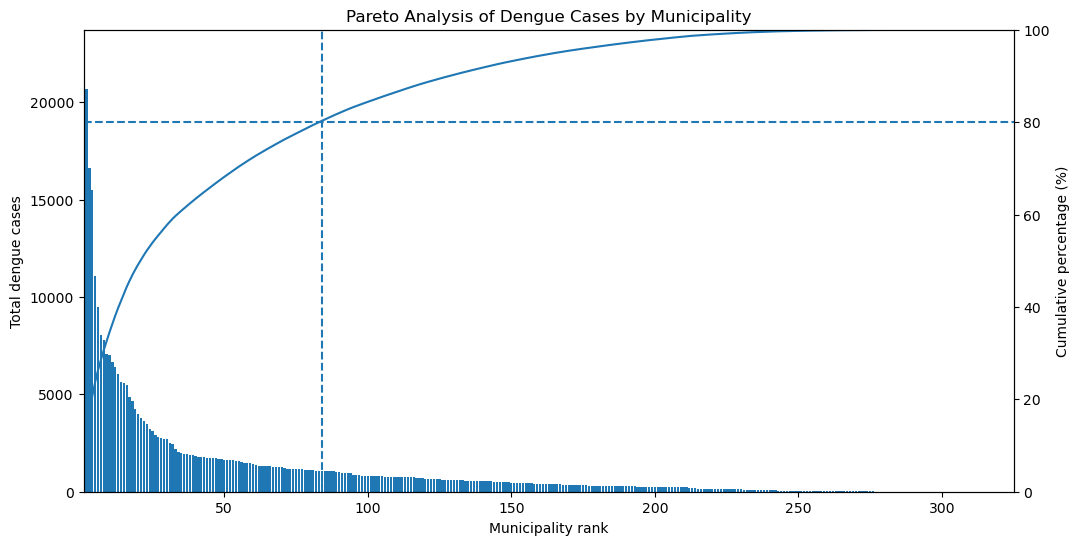

In [110]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(
    x=range(1, len(pareto_df) + 1),
    height=pareto_df["total_cases"]
)
ax1.set_xlabel("Municipality rank")
ax1.set_ylabel("Total dengue cases")
ax1.set_title(
    "Pareto Analysis of Dengue Cases by Municipality"
)
ax1.set_xlim(1, len(pareto_df))

ax2 = ax1.twinx()
ax2.plot(
    range(1, len(pareto_df) + 1),
    pareto_df["cumulative_%"]
)
ax2.set_ylabel("Cumulative percentage (%)")
ax2.set_ylim(0, 100)

ax2.axhline(
    y=80,
    linestyle="--"
)

threshold_row = pareto_df[
    pareto_df["cumulative_%"] >= 80
].iloc[0]

threshold_rank = threshold_row.name + 1

ax1.axvline(
    x=threshold_rank,
    linestyle="--"
)

In [111]:
municipality_percentage = (threshold_rank / len(pareto_df)) * 100
print(f"Approximately {municipality_percentage:.2f}% of municipalities account for 80% of the total dengue cases.")

Approximately 25.85% of municipalities account for 80% of the total dengue cases.


**Interpretation**

The Pareto analysis summarizes how cumulative dengue burden is distributed across municipalities and identifies the share of municipalities accounting for 80% of reported dengue cases.


## 4. Temporal Analysis


### 4.1 Annual Dengue Cases

How has the burden of dengue changed over time in Guatemala from 2012 to 2024?


### 4.2 Year-over-Year Change


In [112]:
year_totals["case difference"] = year_totals["total_cases"].diff()
year_totals["percent_change"] = year_totals["total_cases"].pct_change() * 100

In [113]:
year_totals

,year,total_cases,case difference,percent_change
0,2012,10296,NaN,NaN
1,2013,12833,2537.0,24.640637
2,2014,19735,6902.0,53.783215
3,2015,18612,-1123.0,-5.690398
4,2016,9016,-9596.0,-51.558135
5,2017,4213,-4803.0,-53.271961
6,2018,7523,3310.0,78.566342
7,2019,50597,43074.0,572.564137
8,2020,6011,-44586.0,-88.119849
9,2021,2918,-3093.0,-51.455665


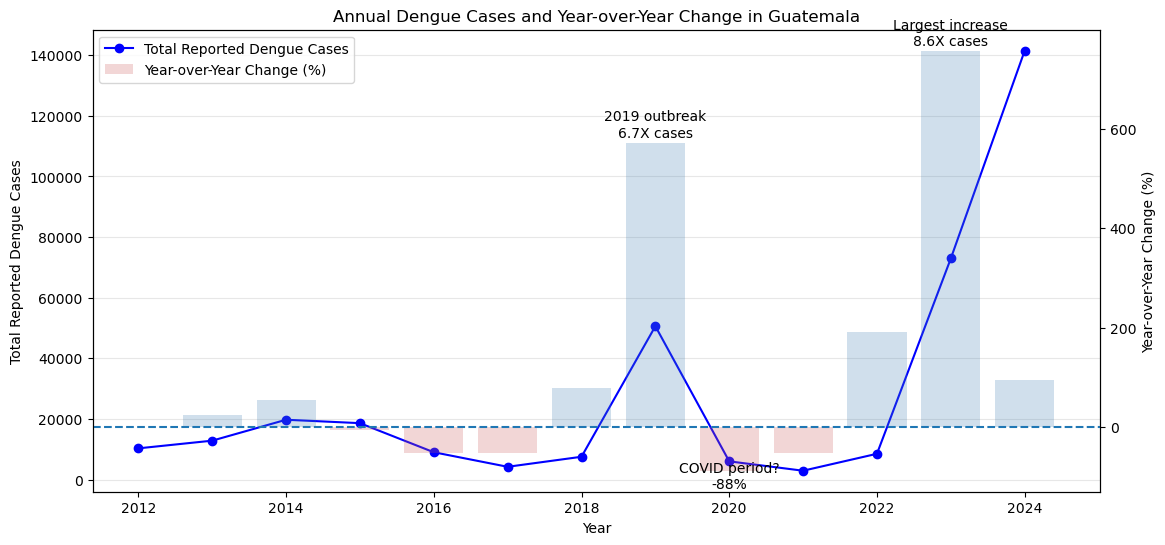

In [114]:
fig, ax1 = plt.subplots(figsize=(13, 6))

ax1.plot(
    year_totals["year"],
    year_totals["total_cases"],
    marker='o',
    label="Total Reported Dengue Cases",
    color='blue'
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Total Reported Dengue Cases")
ax1.set_title("Annual Dengue Cases and Year-over-Year Change in Guatemala")

ax1.grid(
    axis="y",
    alpha=0.3
)

bar_colors = [
    "steelblue" if value >= 0 else "indianred"
    for value in year_totals["percent_change"]
]

ax2 = ax1.twinx()

ax2.bar(
    year_totals["year"],
    year_totals["percent_change"],
    color=bar_colors,
    alpha=0.25,
    label="Year-over-Year Change (%)",
)

ax2.set_ylabel("Year-over-Year Change (%)")
ax2.axhline(
    y=0,
    linestyle="--",
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

annotations = {
    2019: "2019 outbreak\n6.7X cases",
    2020: "COVID period?\n-88%",
    2023: "Largest increase\n8.6X cases"
}

for year, label in annotations.items():

    year_data = year_totals[
        year_totals["year"] == year
    ].iloc[0]

    x_coordinate = year_data["year"]
    y_coordinate = year_data["percent_change"]

    if year == 2020:
        offset = (0, -13)
    else:
        offset = (0, 4)

    ax2.annotate(
        label,
        xy=(x_coordinate, y_coordinate),
        xytext=offset,
        textcoords="offset points",
        ha="center"
    )


### 4.3 Interpretation

Reported dengue cases remained relatively moderate from 2012 through 2018, despite year-to-year fluctuations. In 2019, Guatemala experienced a major outbreak, with reported cases increasing to approximately 6.7 times compared with the previous year. This was followed by a steep decline in 2020. After a short recovery period, another major outbreak occurred in 2023, producing the largest year-over-year percentage increase (8.6 times the previous year's reported cases). Reported cases then reached their highest absolute total in 2024. These major fluctuations may reflect epidemic dynamics, changes in surveillance or reporting, or disruptions associated with the COVID-19 period. Further investigation using additional epidemiological and contextual data is therefore necessary.


## 5. Municipality-Level Spatial Analysis


### 5.1 Municipalities with the Highest Cumulative Burden

Which municipalities contributed the greatest dengue burden?


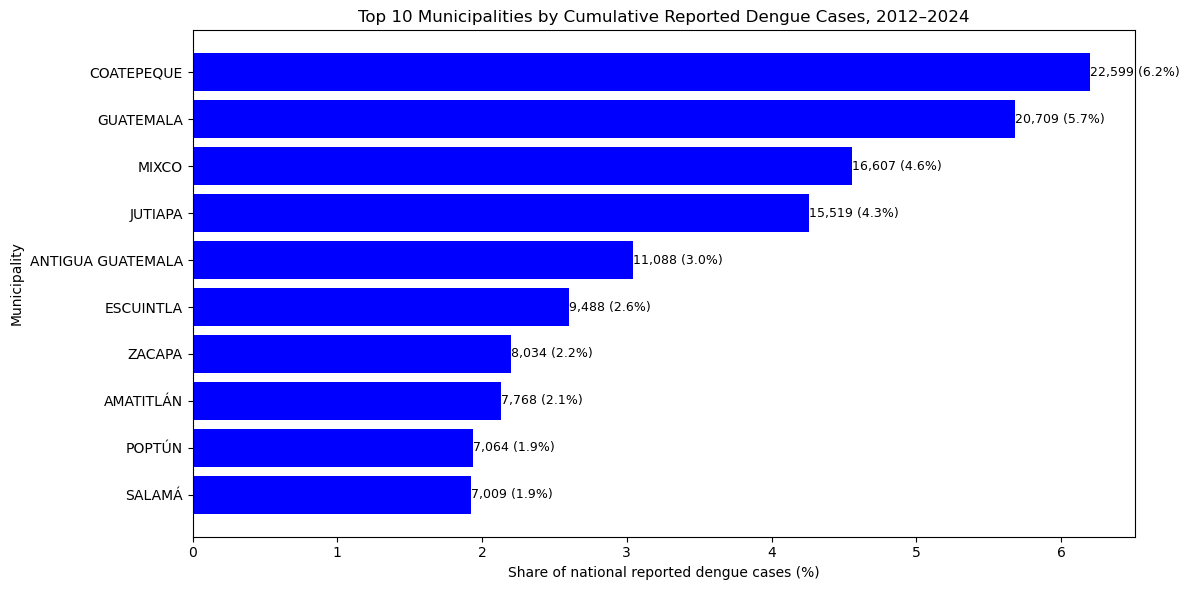

In [115]:
municipality_top_10 = municipality.sort_values(by="total_cases", ascending=False).head(10)
municipality_top_10["percentage_of_cases"] = (
    municipality_top_10["total_cases"] / municipality["total_cases"].sum()
) * 100

plt.figure(figsize=(12, 6))
bars = plt.barh(
    municipality_top_10["municipality"],
    municipality_top_10["percentage_of_cases"],
    color="blue"
)

for bar, cases, pct in zip(
    bars,
    municipality_top_10["total_cases"],
    municipality_top_10["percentage_of_cases"]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"{cases:,} ({pct:.1f}%)",
        va="center",
        ha="left",
        fontsize=9
    )

plt.gca().invert_yaxis()
plt.xlabel("Share of national reported dengue cases (%)")
plt.ylabel("Municipality")
plt.title("Top 10 Municipalities by Cumulative Reported Dengue Cases, 2012–2024")
plt.tight_layout()
plt.show()


There does not seem to be one single municipality that overwhelmingly contributes to the national cumulative dengue burden. It is possible that dengue burden is geographically concentrated at the department level, and that will be explored next.


### 5.2 Share of National Reported Cases


In [116]:
percentage_share_top_10 = municipality_top_10["percentage_of_cases"].sum()
print(f"The top 10 municipalities account for approximately {percentage_share_top_10:.2f}% of the total reported dengue cases in Guatemala from 2012 to 2024.")

The top 10 municipalities account for approximately 34.52% of the total reported dengue cases in Guatemala from 2012 to 2024.


The ten municipalities with the highest cumulative dengue burden accounted for approximately 34.5% of all reported dengue cases in Guatemala between 2012 and 2024. Although no individual municipality contributed more than 6.2% of the national total, a small group of municipalities accounted for more than one-third of all reported cases. This suggests that dengue burden is geographically concentrated rather than evenly distributed across municipalities.


### 5.3 Persistence in the Annual Top 10


In [117]:
municipalities_grouped_year = year_municipality.groupby('year')
top10_each_year = municipalities_grouped_year.apply(
    lambda group: group.sort_values('total_cases', ascending=False).head(10)
)
top10_each_year = top10_each_year.reset_index(drop=False)
top10_each_year = top10_each_year.drop(columns="level_1")

top10_frequency = (
    top10_each_year["municipality"]
    .value_counts()
    .reset_index()
)

top10_frequency.columns = [
    "municipality",
    "years_in_top_10"
]
top10_frequency


,municipality,years_in_top_10
0,COATEPEQUE,12
1,GUATEMALA,10
2,ZACAPA,9
3,JUTIAPA,7
4,PUERTO BARRIOS,7
5,ANTIGUA GUATEMALA,7
6,ESCUINTLA,6
7,MIXCO,6
8,SALAMÁ,5
9,AMATITLÁN,4


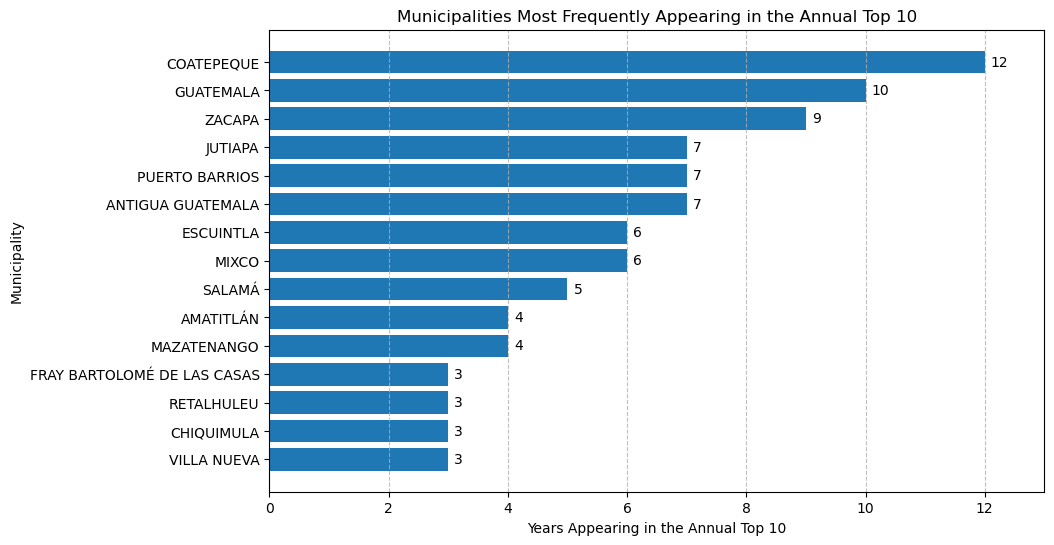

In [118]:
top15 = top10_frequency.head(15)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top15["municipality"],
    top15["years_in_top_10"]
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center",
        ha="left"
    )

ax.set_xlabel("Years Appearing in the Annual Top 10")
ax.set_ylabel("Municipality")
ax.set_title("Municipalities Most Frequently Appearing in the Annual Top 10")

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.8,
    alpha=0.8
)
ax.set_xlim(0, 13)

ax.invert_yaxis()

### 5.4 Interpretation

Although only 47 of the 325 municipalities (14%) appeared in the annual Top 10 at least once during the study period, these municipalities included several persistent high-burden locations. Coatepeque appeared in the annual Top 10 during 12 of the 13 years analyzed, followed by Guatemala (10 years) and Zacapa (9 years). Together with the finding that the Top 10 municipalities accounted for 34.5% of all reported dengue cases, these results suggest that dengue burden was geographically concentrated in a relatively small subset of municipalities rather than being evenly distributed across Guatemala.


## 6. Department-Level Spatial Analysis


### 6.1 Cumulative Dengue Burden by Department

Is dengue burden even more geographically concentrated when municipalities are aggregated into departments?


In [119]:
municipality_aggregate = (
    municipality
    .groupby('department')
    .agg(total_cases=('total_cases', 'sum'))
    .sort_values(by='total_cases', ascending=False)
    .reset_index()
)

national_cases = municipality_aggregate['total_cases'].sum()

municipality_aggregate["percentage_of_cases"] = (
    municipality_aggregate["total_cases"] / national_cases
) * 100


### 6.2 Share of National Reported Cases


Text(0.5, 1.0, 'Share of National Reported Dengue Cases by Department, 2012–2024')

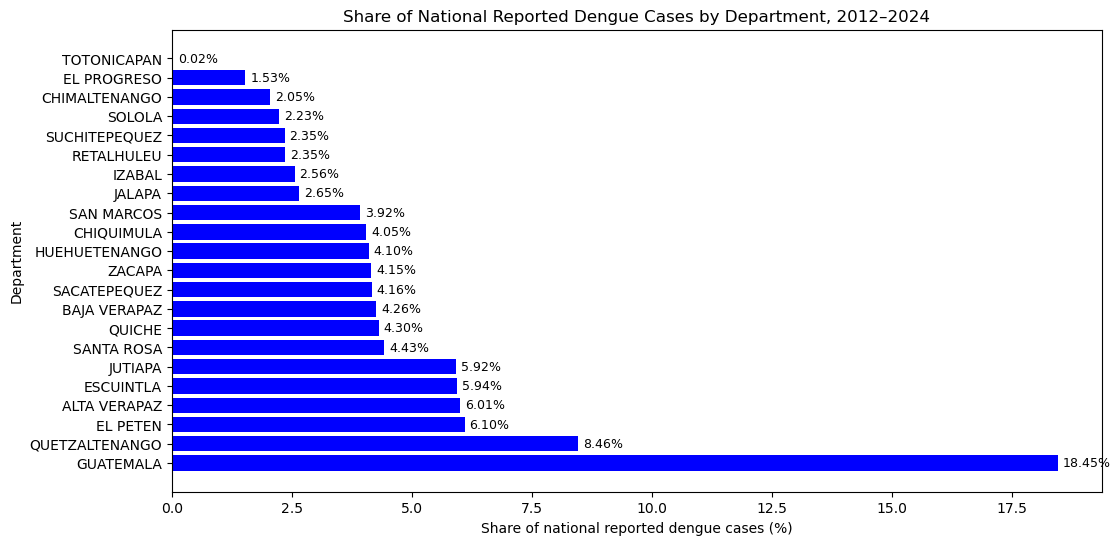

In [120]:
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    municipality_aggregate["department"],
    municipality_aggregate["percentage_of_cases"],
    color="blue"
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}%",
        va="center",
        ha="left",
        fontsize=9
    )

ax.set_xlabel("Share of national reported dengue cases (%)")
ax.set_ylabel("Department")
ax.set_title("Share of National Reported Dengue Cases by Department, 2012–2024")


### 6.3 Interpretation

The distribution of reported dengue cases across departments is not uniform. Guatemala Department accounts for nearly one-fifth of all reported cases during the study period, making it the dominant contributor. Quetzaltenango forms a second tier with approximately 8.5% of national cases, while most remaining departments contribute between 2% and 6%, suggesting a moderate level of geographic concentration rather than an even distribution across the country.


### 6.4 Department patterns over time


In [121]:
#year_cumulative_department = year_municipality.groupby(['year', 'department']).sum().reset_index()

municipality["municipality"].is_unique
municipality[municipality["municipality"].duplicated(keep=False)]

,municipality,department,total_cases
51,LA DEMOCRACIA,HUEHUETENANGO,1606
55,LA LIBERTAD,EL PETEN,1520
118,LA DEMOCRACIA,ESCUINTLA,687
167,LA LIBERTAD,HUEHUETENANGO,363
182,SAN PEDRO SACATEPÉQUEZ,GUATEMALA,304
206,SAN LORENZO,SUCHITEPEQUEZ,231
236,SANTA BÁRBARA,SUCHITEPEQUEZ,87
244,SANTA BÁRBARA,HUEHUETENANGO,56
282,SAN PEDRO SACATEPÉQUEZ,SAN MARCOS,8
317,SAN LORENZO,SAN MARCOS,2


In [122]:
year_municipality[

    year_municipality["municipality"] == "LA DEMOCRACIA"

]

,year,municipality,department,total_cases
73,2012,LA DEMOCRACIA,ESCUINTLA,23
235,2013,LA DEMOCRACIA,HUEHUETENANGO,95
260,2013,LA DEMOCRACIA,ESCUINTLA,47
498,2014,LA DEMOCRACIA,HUEHUETENANGO,30
504,2014,LA DEMOCRACIA,ESCUINTLA,25
650,2015,LA DEMOCRACIA,HUEHUETENANGO,195
678,2015,LA DEMOCRACIA,ESCUINTLA,69
875,2016,LA DEMOCRACIA,HUEHUETENANGO,44
882,2016,LA DEMOCRACIA,ESCUINTLA,38
1077,2017,LA DEMOCRACIA,HUEHUETENANGO,42


## 7. Preliminary Conclusions

Final conclusions will be written after the department-level analysis is completed.


## 8. Limitations and Future Work

This section will be completed after the department-level analysis is finalized.
